In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("transfusion.csv")
df.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [4]:
df

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
743,23,2,500,38,0
744,21,2,500,52,0
745,23,3,750,62,0
746,39,1,250,39,0


In [5]:
df.columns = ["Recency", "Frequency", "Monetary", "Time", "Target"]

In [6]:
df.head()

,Recency,Frequency,Monetary,Time,Target
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    748 non-null    int64
 1   Frequency  748 non-null    int64
 2   Monetary   748 non-null    int64
 3   Time       748 non-null    int64
 4   Target     748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


In [8]:
df.describe()

,Recency,Frequency,Monetary,Time,Target
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


In [9]:
df.isnull().sum()

Recency      0
Frequency    0
Monetary     0
Time         0
Target       0
dtype: int64

In [30]:
df.corr()

,Recency,Frequency,Monetary,Time,Target
Recency,1.000000,-0.182745,-0.182745,0.160618,-0.279869
Frequency,-0.182745,1.000000,1.000000,0.634940,0.218633
Monetary,-0.182745,1.000000,1.000000,0.634940,0.218633
Time,0.160618,0.634940,0.634940,1.000000,-0.035854
Target,-0.279869,0.218633,0.218633,-0.035854,1.000000


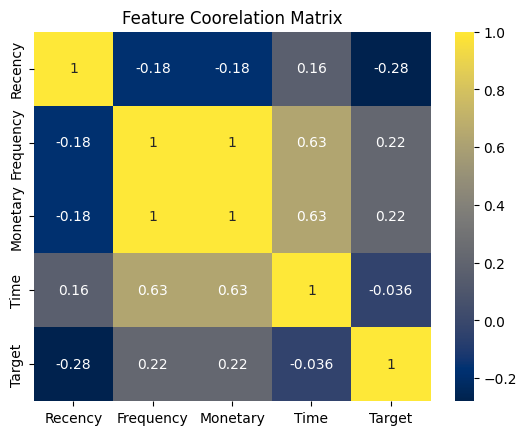

In [36]:
import seaborn as sns
plt.Figure(figsize=(10,5))
sns.heatmap(df.corr(),cmap='cividis',annot=True)
plt.title("Feature Coorelation Matrix")
plt.show()

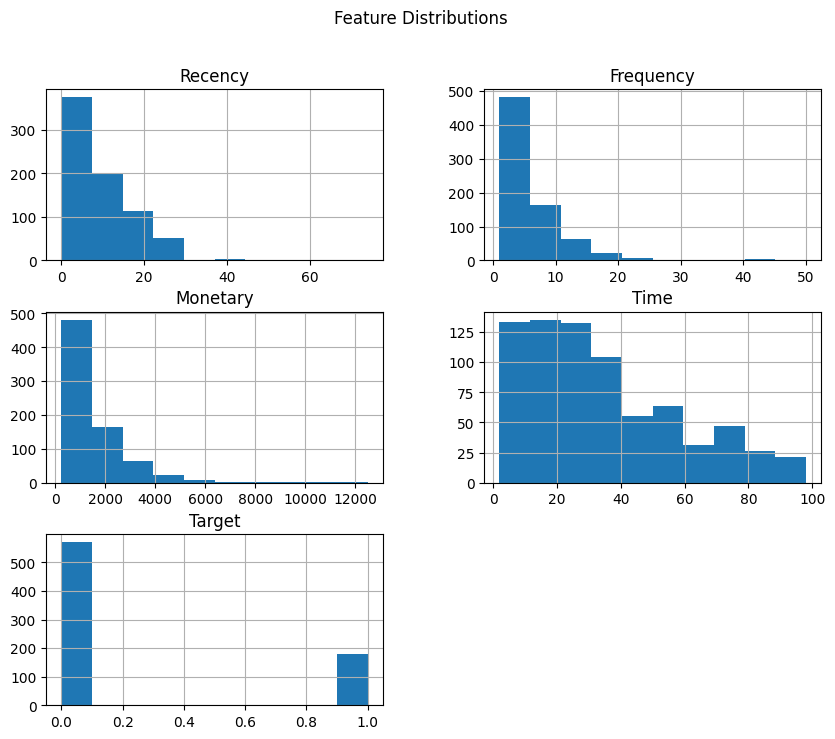

In [32]:
df.hist(figsize=(10, 8),bins=10)
plt.suptitle("Feature Distributions")
plt.show()

In [12]:
x=df.drop(['Target'],axis=1)
y=df['Target']

In [13]:
print(x.shape)
print(y.shape)

(748, 4)
(748,)


In [14]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

In [16]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(598, 4)
(150, 4)
(598,)
(150,)


In [22]:
model=AdaBoostClassifier(n_estimators=200,learning_rate=0.2,random_state=42)
model.fit(x_train,y_train)

,estimator,None
,n_estimators,200
,learning_rate,0.2
,algorithm,'deprecated'
,random_state,42


In [23]:
y_pred = model.predict(x_test)

In [24]:
print(y_pred)
print(y_test)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
580    0
356    0
133    0
250    0
299    0
      ..
627    0
90     1
642    0
683    0
69     0
Name: Target, Length: 150, dtype: int64


In [25]:
accuracy=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)

print("Accuracy: ",accuracy)
print("Classification Report: \n",report)

Accuracy:  0.7733333333333333
Classification Report: 
               precision    recall  f1-score   support

           0       0.77      1.00      0.87       113
           1       1.00      0.08      0.15        37

    accuracy                           0.77       150
   macro avg       0.88      0.54      0.51       150
weighted avg       0.83      0.77      0.69       150



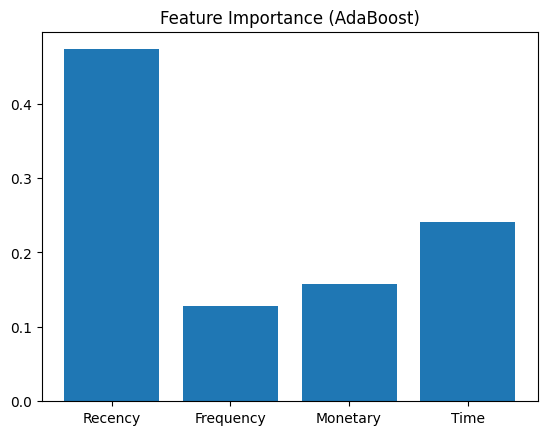

In [29]:
importance = model.feature_importances_
features = x.columns
plt.bar(features, importance)
plt.title("Feature Importance (AdaBoost)")
plt.show()

In [37]:
import joblib
joblib.dump(model,"AdaBoost_model.pkl")
joblib.dump(scaler,"Scaled_transfusion.pkl")


['Scaled_transfusion.pkl']